In [69]:
# 1. Environment Setup and Advanced Proxy Configuration
import os
import sys
import ssl
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, TensorDataset
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
proxy = 'http://127.0.0.1:7890'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

ssl._create_default_https_context = ssl._create_unverified_context
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

In [71]:
# 2. Preparing the environment
def load_official_bas(n_qubits=4, noise_std=0.1, total_samples=800, test_size=0.2):
    try:
        # 加载官方数据集
        datasets = qml.data.load("other", name="bars-and-stripes")
        ds = datasets[0]
        
        # 1. 整合所有可用的原始数据
        X_raw = np.concatenate([np.array(ds.train['4']['inputs']), np.array(ds.test['4']['inputs'])], axis=0)
        y_raw = np.concatenate([np.array(ds.train['4']['labels']), np.array(ds.test['4']['labels'])], axis=0)
        
        # 2. 扩充数据量到 800 (通过随机重复采样)
        # 注意：BAS 4x4 原始模式有限，扩充后通过后续加噪来产生差异化
        np.random.seed(42) # 保证实验可复现
        indices = np.random.choice(len(X_raw), size=total_samples, replace=True)
        X_all = X_raw[indices]
        y_all = y_raw[indices]

        # 3. 使用 train_test_split 按照 0.2 比例重新划分 (640 训练, 160 测试)
        X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
            X_all, y_all, test_size=test_size, random_state=42
        )

        # 4. 注入加性高斯噪声 (在扩充后的数据集上操作)
        X_train_noisy = X_train_np + np.random.normal(0, noise_std, X_train_np.shape)
        X_test_noisy = X_test_np + np.random.normal(0, noise_std, X_test_np.shape)
        
        # 5. 数据归一化
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train_noisy)
        X_test_scaled = scaler.transform(X_test_noisy)
        
        # 6. PCA 降维 (保持 input 维度与 n_qubits 一致)
        pca = PCA(n_components=n_qubits)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)
        
        # 标签映射: -1 -> 0, 1 -> 1
        y_train_mapped = np.where(y_train_np == -1, 0, 1)
        y_test_mapped = np.where(y_test_np == -1, 0, 1)

        # 转换为 Tensor 格式
        X_train = torch.tensor(X_train_pca, dtype=torch.float32).unsqueeze(-1)
        X_test = torch.tensor(X_test_pca, dtype=torch.float32).unsqueeze(-1)
        y_train = torch.tensor(y_train_mapped, dtype=torch.long)
        y_test = torch.tensor(y_test_mapped, dtype=torch.long)

        return X_train, y_train, X_test, y_test
            
    except Exception as e:
        print(f"Failed to load: {e}")
        raise

# 调用并指定 800 个数据和 0.2 的比例
X_train, y_train, X_test, y_test = load_official_bas(
    n_qubits=4, noise_std=0.5, total_samples=800, test_size=0.2
)

# 打印验证结果
print(f"训练集大小: {X_train.shape[0]} (预期 640)")
print(f"测试集大小: {X_test.shape[0]} (预期 160)")

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16, shuffle=False)

训练集大小: 640 (预期 640)
测试集大小: 160 (预期 160)


In [72]:
# 3. Definition of a quantum model

n_qubits = 4
n_layers = 1
noise_prob = 0.1

dev = qml.device("default.mixed", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def qnode(inputs, weights):
    # 1. 数据编码
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    
    # 2. 特征提取 (减少层数)
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
        
    # 3. 集中噪声引入 (改为只在输出前注入一次)
    # 这样可以模拟整个过程受到的综合噪声，但计算量减半
    for j in range(n_qubits):
        qml.DepolarizingChannel(noise_prob, wires=j)
            
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class QLSTMCell(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, n_qubits=4, n_layers=2):
        super(QLSTMCell, self).__init__()
        self.hidden_size = hidden_size
        self.n_qubits = n_qubits

        self.cl_in = nn.Linear(input_size + hidden_size, n_qubits)
        self.cl_out = nn.Linear(n_qubits, 4 * hidden_size)

        # 【优化】权重的初始化对收敛速度影响很大
        nn.init.orthogonal_(self.cl_in.weight) 
        nn.init.xavier_uniform_(self.cl_out.weight)

        # 确保这里的 n_layers 和 qnode 里的 weights 形状严格对应
        weight_shapes = {"weights": (n_layers, n_qubits)}
        self.vqc = qml.qnn.TorchLayer(qnode, weight_shapes)

    def forward(self, x_t, h_t_1, c_t_1):
        concat_input = torch.cat([x_t, h_t_1], dim=1)
        # 使用 pi 缩放是为了适配 AngleEmbedding 的弧度要求
        vqc_input = torch.tanh(self.cl_in(concat_input)) * math.pi
        
        q_out = self.vqc(vqc_input)
        gates = self.cl_out(q_out)
        
        f_t = torch.sigmoid(gates[:, 0:self.hidden_size])
        i_t = torch.sigmoid(gates[:, self.hidden_size:2*self.hidden_size])
        g_t = torch.tanh(gates[:, 2*self.hidden_size:3*self.hidden_size])
        o_t = torch.sigmoid(gates[:, 3*self.hidden_size:4*self.hidden_size])
        
        c_t = f_t * c_t_1 + i_t * g_t
        h_t = o_t * torch.tanh(c_t)
        return h_t, c_t

class QuantumLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, n_layers=2): # 默认改为 1
        super().__init__()
        self.hidden_size = hidden_size
        self.qlstm_cell = QLSTMCell(input_size=input_size, hidden_size=hidden_size, n_layers=n_layers)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        h_t = torch.zeros(x.size(0), self.hidden_size).to(x.device)
        c_t = torch.zeros(x.size(0), self.hidden_size).to(x.device)
        
        # 如果序列太长（比如 16），建议只取前几个或后几个，或者在这里做步长采样
        # 例如: for t in range(0, x.size(1), 2): 会快一倍
        for t in range(x.size(1)):
            h_t, c_t = self.qlstm_cell(x[:, t, :], h_t, c_t)
            
        return self.fc(h_t)

In [73]:
# 4. Definition of the classical model
class ClassicalLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=8):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

In [74]:
# 5. Unifying the training and evaluation functions
def run_experiment(model, loader, x_test, y_test, epochs=200, lr=0.002, patience=10):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history_train_loss = []
    history_test_loss = []
    
    best_loss = float('inf')
    counter = 0
    
    start_train = time.time()
    for epoch in range(epochs):
        model.train()
        l_sum = 0
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            l_sum += loss.item()
        
        avg_train_loss = l_sum / len(loader)
        history_train_loss.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            test_out = model(x_test)
            test_loss = criterion(test_out, y_test).item()
            history_test_loss.append(test_loss)
            
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

        if test_loss < best_loss:
            best_loss = test_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"--- Early Stopping at epoch {epoch+1} ---")
                break

    train_time = time.time() - start_train
    
    model.eval()
    start_inf = time.time()
    with torch.no_grad():
        out = model(x_test)
        inf_time = (time.time() - start_inf) / len(x_test)
        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)
    
    y_true = y_test.numpy()
    y_pred = preds.numpy()
    y_score = probs[:, 1].numpy()
    
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_score),
        "Train_Time": train_time,
        "Inf_Time": inf_time,
        "Loss_Hist": history_train_loss,
        "Test_Loss_Hist": history_test_loss,
        "y_true": y_true, 
        "y_score": y_score
    }

In [75]:
# 6. Training quantum models
print(" Training QLSTM ...")
q_results = run_experiment(QuantumLSTMModel(hidden_size=8), train_loader, X_test, y_test, epochs=200, lr=0.002)

 Training QLSTM ...
Epoch [1/200] | Train Loss: 0.7001 | Test Loss: 0.6938
Epoch [5/200] | Train Loss: 0.6935 | Test Loss: 0.6932
Epoch [10/200] | Train Loss: 0.6935 | Test Loss: 0.6926
Epoch [15/200] | Train Loss: 0.6747 | Test Loss: 0.6642
Epoch [20/200] | Train Loss: 0.5864 | Test Loss: 0.5697
Epoch [25/200] | Train Loss: 0.5040 | Test Loss: 0.4808
Epoch [30/200] | Train Loss: 0.4711 | Test Loss: 0.4604
Epoch [35/200] | Train Loss: 0.4435 | Test Loss: 0.4244
Epoch [40/200] | Train Loss: 0.4153 | Test Loss: 0.4194
Epoch [45/200] | Train Loss: 0.4102 | Test Loss: 0.4045
Epoch [50/200] | Train Loss: 0.4170 | Test Loss: 0.3991
Epoch [55/200] | Train Loss: 0.3983 | Test Loss: 0.4063
Epoch [60/200] | Train Loss: 0.3898 | Test Loss: 0.4076
Epoch [65/200] | Train Loss: 0.3903 | Test Loss: 0.4033
--- Early Stopping at epoch 66 ---


In [76]:
# 7. Training classic models
print(" Training LSTM ...")
c_results = run_experiment(ClassicalLSTM(), train_loader, X_test, y_test, epochs=200, lr=0.002)

 Training LSTM ...
Epoch [1/200] | Train Loss: 0.6946 | Test Loss: 0.6937
Epoch [5/200] | Train Loss: 0.6930 | Test Loss: 0.6937
Epoch [10/200] | Train Loss: 0.6936 | Test Loss: 0.6934
Epoch [15/200] | Train Loss: 0.6893 | Test Loss: 0.6885
Epoch [20/200] | Train Loss: 0.6556 | Test Loss: 0.6504
Epoch [25/200] | Train Loss: 0.5503 | Test Loss: 0.5579
Epoch [30/200] | Train Loss: 0.4846 | Test Loss: 0.4928
Epoch [35/200] | Train Loss: 0.4365 | Test Loss: 0.4516
Epoch [40/200] | Train Loss: 0.4102 | Test Loss: 0.4157
Epoch [45/200] | Train Loss: 0.3867 | Test Loss: 0.3933
Epoch [50/200] | Train Loss: 0.3671 | Test Loss: 0.3782
Epoch [55/200] | Train Loss: 0.3577 | Test Loss: 0.3640
Epoch [60/200] | Train Loss: 0.3483 | Test Loss: 0.3586
Epoch [65/200] | Train Loss: 0.3414 | Test Loss: 0.3447
Epoch [70/200] | Train Loss: 0.3353 | Test Loss: 0.3410
Epoch [75/200] | Train Loss: 0.3299 | Test Loss: 0.3391
Epoch [80/200] | Train Loss: 0.3227 | Test Loss: 0.3309
Epoch [85/200] | Train Loss: 0.

In [77]:
# 8. Model Evaluation Results Report
print("\n" + "="*65)
print(f"{'Evaluation criteria (Metric)':<30} | {'QLSTM':<15} | {'Classical LSTM':<15}")
print("-"*65)
metrics_list = [
    ("Accuracy", "Accuracy"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("F1-Score", "F1"),
    ("AUC-ROC", "AUC"),
]
for label, key in metrics_list:
    print(f"{label:<30} | {q_results[key]:<15.4f} | {c_results[key]:<15.4f}")

print("-"*65)
print(f"{'Train Time/s':<30} | {q_results['Train_Time']:<15.2f} | {c_results['Train_Time']:<15.2f}")
print(f"{'Inf Time/ms':<30} | {q_results['Inf_Time']*1000:<15.4f} | {c_results['Inf_Time']*1000:<15.4f}")
print("="*65 + "\n")


Evaluation criteria (Metric)   | QLSTM           | Classical LSTM 
-----------------------------------------------------------------
Accuracy                       | 0.7750          | 0.8500         
Precision                      | 0.7529          | 0.8235         
Recall                         | 0.8101          | 0.8861         
F1-Score                       | 0.7805          | 0.8537         
AUC-ROC                        | 0.8903          | 0.9441         
-----------------------------------------------------------------
Train Time/s                   | 564.41          | 18.50          
Inf Time/ms                    | 1.2342          | 0.0072         



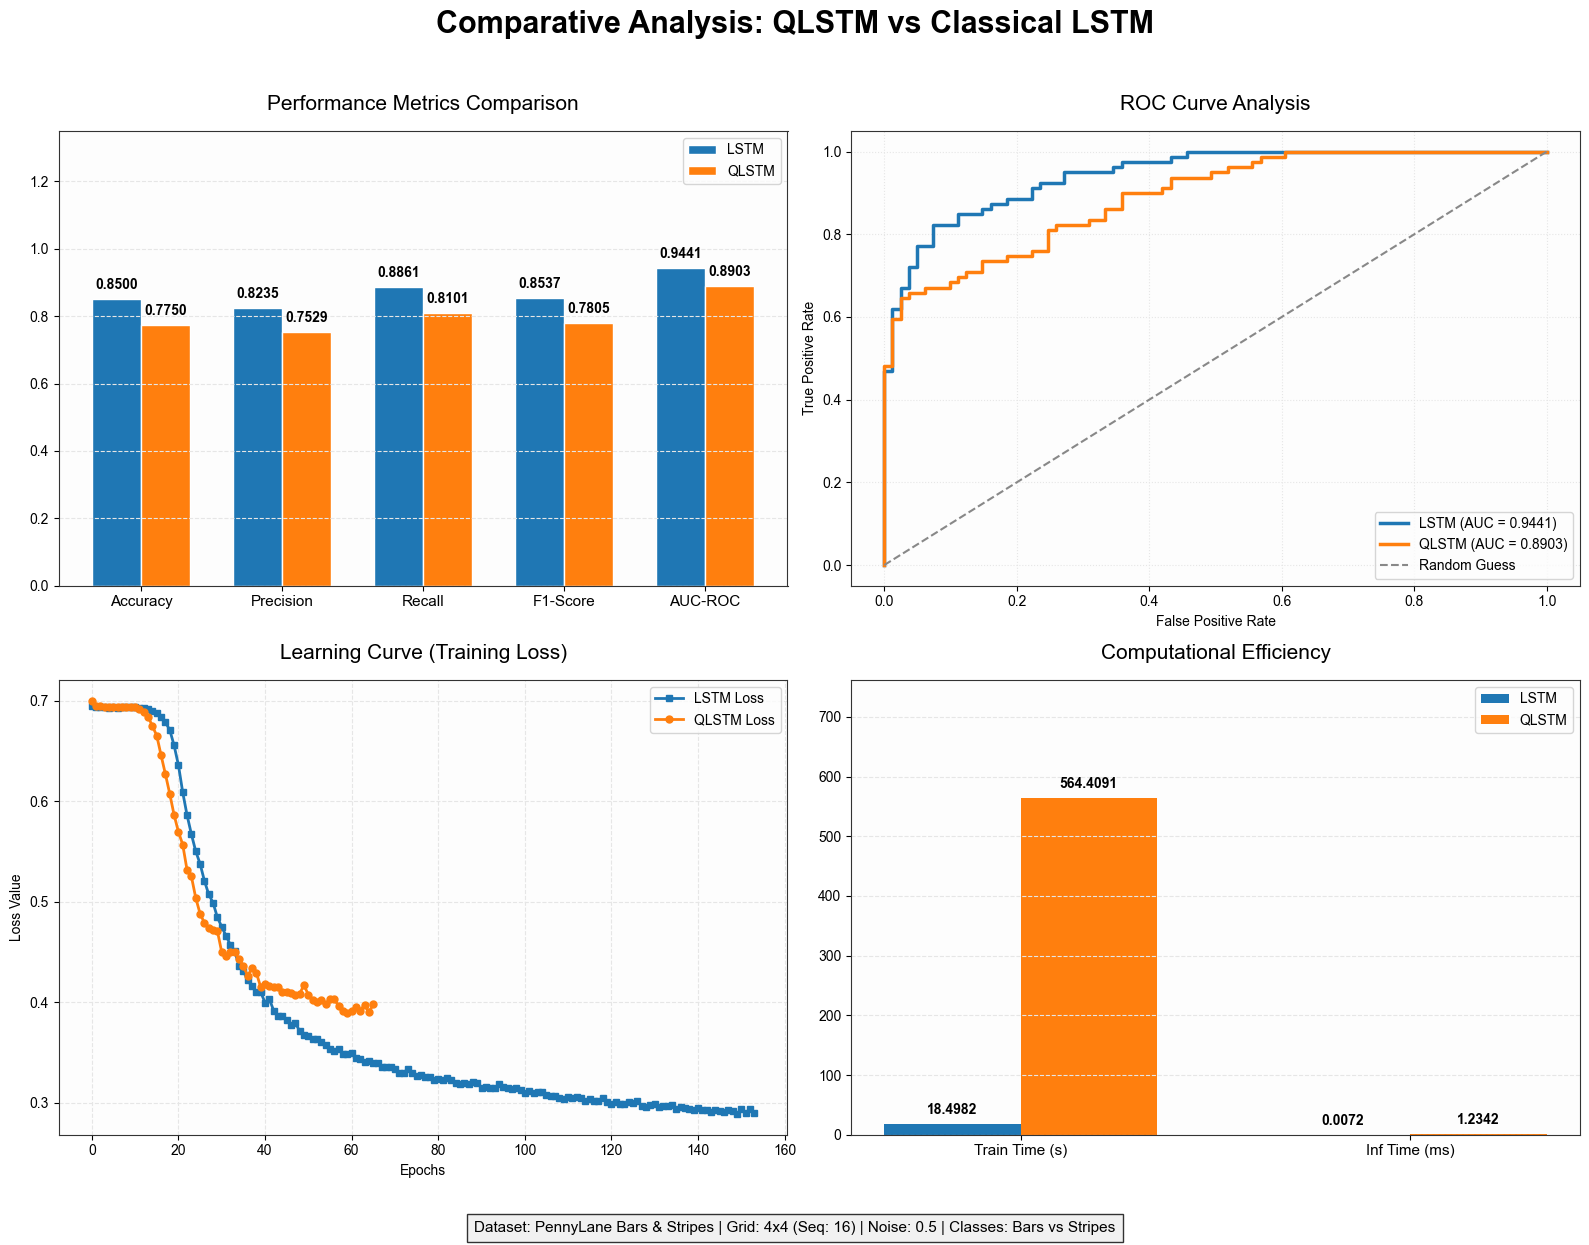

In [78]:
# 9. Visual comparative analysis
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['axes.facecolor'] = '#fdfdfd'
plt.rcParams['grid.color'] = '#e6e6e6'
plt.rcParams['axes.edgecolor'] = '#333333'

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Comparative Analysis: QLSTM vs Classical LSTM', 
             fontsize=22, fontweight='bold', y=0.96)

lstm_color = '#1f77b4'
qlstm_color = '#ff7f0e'

# --- (1) Top-Left：Comparison of Comprehensive Assessment Indicators (Bar Chart) ---
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
q_vals = [q_results['Accuracy'], q_results['Precision'], q_results['Recall'], q_results['F1'], q_results['AUC']]
c_vals = [c_results['Accuracy'], c_results['Precision'], c_results['Recall'], c_results['F1'], c_results['AUC']]

x = np.arange(len(labels))
width = 0.35

bar_c = axes[0, 0].bar(x - width/2, c_vals, width, label='LSTM', color=lstm_color, edgecolor='white')
bar_q = axes[0, 0].bar(x + width/2, q_vals, width, label='QLSTM', color=qlstm_color, edgecolor='white')

def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(bar_c, axes[0, 0])
autolabel(bar_q, axes[0, 0])

axes[0, 0].set_ylim(0, 1.35)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels, fontsize=11)
axes[0, 0].set_title('Performance Metrics Comparison', fontsize=15, pad=15)
axes[0, 0].legend(loc='upper right', frameon=True)
axes[0, 0].grid(True, axis='y', linestyle='--')

# --- (2) Top-Right：Comparison of ROC Curves ---
c_fpr, c_tpr, _ = roc_curve(c_results['y_true'], c_results['y_score'])
q_fpr, q_tpr, _ = roc_curve(q_results['y_true'], q_results['y_score'])

axes[0, 1].plot(c_fpr, c_tpr, color=lstm_color, lw=2.5, label=f'LSTM (AUC = {c_results["AUC"]:.4f})')
axes[0, 1].plot(q_fpr, q_tpr, color=qlstm_color, lw=2.5, label=f'QLSTM (AUC = {q_results["AUC"]:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='#888888', lw=1.5, linestyle='--', label='Random Guess')

axes[0, 1].set_title('ROC Curve Analysis', fontsize=15, pad=15)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc='lower right', frameon=True)
axes[0, 1].grid(True, linestyle=':')

# --- (3) Bottom-Left：Learning curve (Loss) ---
axes[1, 0].plot(c_results['Loss_Hist'], color=lstm_color, label='LSTM Loss', marker='s', markersize=5, lw=2)
axes[1, 0].plot(q_results['Loss_Hist'], color=qlstm_color, label='QLSTM Loss', marker='o', markersize=5, lw=2)

axes[1, 0].set_title('Learning Curve (Training Loss)', fontsize=15, pad=15)
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Loss Value')
axes[1, 0].legend(loc='upper right', frameon=True)
axes[1, 0].grid(True, linestyle='--')

# --- (4) Bottom-Right：Comparison of computational efficiency ---
eff_labels = ['Train Time (s)', 'Inf Time (ms)']
c_eff = [c_results['Train_Time'], c_results['Inf_Time'] * 1000]
q_eff = [q_results['Train_Time'], q_results['Inf_Time'] * 1000]

x_e = np.arange(len(eff_labels))
max_val = max(max(q_eff), max(c_eff))

bar_ce = axes[1, 1].bar(x_e - width/2, c_eff, width, label='LSTM', color=lstm_color)
bar_qe = axes[1, 1].bar(x_e + width/2, q_eff, width, label='QLSTM', color=qlstm_color)

autolabel(bar_ce, axes[1, 1])
autolabel(bar_qe, axes[1, 1])

axes[1, 1].set_ylim(0, max_val * 1.35) 
axes[1, 1].set_xticks(x_e)
axes[1, 1].set_xticklabels(eff_labels, fontsize=11)
axes[1, 1].set_title('Computational Efficiency', fontsize=15, pad=15)
axes[1, 1].legend(loc='upper right', frameon=True)
axes[1, 1].grid(True, axis='y', linestyle='--')

dataset_info = "Dataset: PennyLane Bars & Stripes | Grid: 4x4 (Seq: 16) | Noise: 0.5 | Classes: Bars vs Stripes"
plt.figtext(0.5, 0.02, dataset_info, ha="center", fontsize=11, 
            bbox={"facecolor":"#eeeeee", "alpha":0.8, "pad":5}, fontname='Arial')

plt.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()